In [1]:
#para iniciar cada clase
from google.colab import drive
drive.mount('/content/drive')

%cd /content/drive/MyDrive/EstructuraDatos_2026_02
!pip install -q -r requirements.txt

import sys
sys.path.append('/content/drive/MyDrive/EstructuraDatos_2026_02')

Mounted at /content/drive
/content/drive/MyDrive/EstructuraDatos_2026_02
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.2/17.2 MB 76.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 915.1/915.1 kB 37.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.5/77.5 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.8/59.8 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 108.8 MB/s eta 0:00:00


In [2]:
def p_cuadratico(a, x):
    suma = 0
    for i in range(len(a)):
        potencia = 1
        for j in range(i):
            potencia = potencia * x
        suma = suma + a[i] * potencia
    return suma

In [3]:
def p_mejorado(a, x):
    suma = 0
    potencia = 1
    for i in range(len(a)):
        suma = suma + a[i] * potencia
        potencia = potencia * x
    return suma

In [4]:
def horner(a, x):
    suma = a[-1]
    for i in range(len(a) - 2, -1, -1):
        suma = a[i] + x * suma
    return suma

In [5]:
  a = [3, 2, 5, -1, 4]
x = 2

print("p_cuadratico:", p_cuadratico(a, x))
print("p_mejorado:  ", p_mejorado(a, x))
print("horner:      ", horner(a, x))

p_cuadratico: 83
p_mejorado:   83
horner:       83


In [8]:
def division_sintetica(a, r):
    coeficientes = a[::-1]
    cociente = [coeficientes[0]]
    for i in range(1, len(coeficientes)):
        nuevo = coeficientes[i] + r * cociente[-1]
        cociente.append(nuevo)
    residuo = cociente[-1]
    return residuo

In [9]:
def division_sintetica_completa(a, r):
    coeficientes = a[::-1]
    fila = [coeficientes[0]]
    for i in range(1, len(coeficientes)):
        fila.append(coeficientes[i] + r * fila[-1])
    residuo = fila[-1]
    cociente = fila[:-1]
    return cociente, residuo

cociente, residuo = division_sintetica_completa([3, 2, 5, -1, 4], 2)
print("cociente:", cociente)
print("residuo = p(2) =", residuo)

cociente: [4, 7, 19, 40]
residuo = p(2) = 83


In [12]:
ns_log = list(range(1, 10001))

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(ns_log, [operaciones_A(n) for n in ns_log], label=r"A: $n^2 + n$", linewidth=2)
ax.plot(ns_log, [operaciones_B(n) for n in ns_log], label=r"B: $n^3/200$", linewidth=2)
ax.axvline(n0, color="gray", linestyle="--", label=f"$n_0$ = {n0}")

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("n (escala log)")
ax.set_ylabel("operaciones (escala log)")
ax.set_title("Escala log-log: para n >= 201 A siempre gana")
ax.legend()
ax.grid(True, which="both", alpha=0.3)
plt.show()def operaciones_A(n):
    return n**2 + n

def operaciones_B(n):
    return n**3 / 200

raiz = 100 + 10200 ** 0.5
print("raiz exacta:", raiz)

n0 = 1
while operaciones_A(n0) >= operaciones_B(n0):
    n0 = n0 + 1
print("n0 =", n0)

for n in [199, 200, 201, 202]:
    mejor = "A" if operaciones_A(n) < operaciones_B(n) else "B"
    print(f"n = {n:4d}   A = {operaciones_A(n):10.1f}   B = {operaciones_B(n):10.1f}   mejor = {mejor}")

raiz exacta: 200.99504938362077
n0 = 201
n =  199   A =    39800.0   B =    39403.0   mejor = B
n =  200   A =    40200.0   B =    40000.0   mejor = B
n =  201   A =    40602.0   B =    40603.0   mejor = A
n =  202   A =    41006.0   B =    41212.0   mejor = A


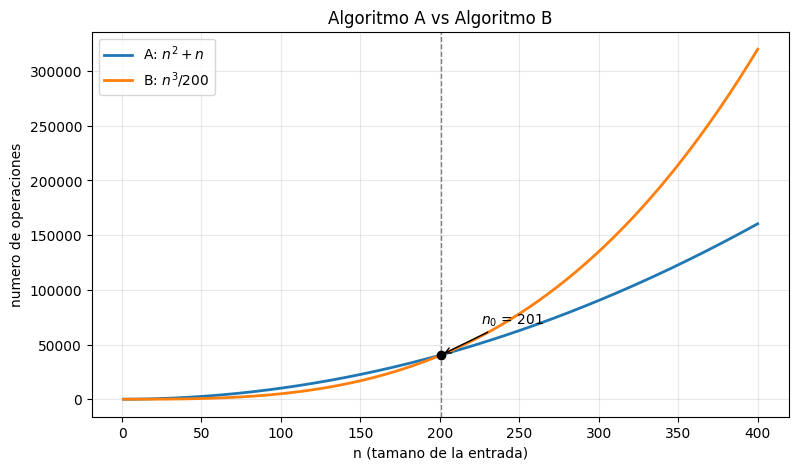

In [13]:
import matplotlib.pyplot as plt

ns = list(range(1, 401))
ys_A = [operaciones_A(n) for n in ns]
ys_B = [operaciones_B(n) for n in ns]

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(ns, ys_A, label=r"A: $n^2 + n$", linewidth=2)
ax.plot(ns, ys_B, label=r"B: $n^3/200$", linewidth=2)

ax.axvline(n0, color="gray", linestyle="--", linewidth=1)
ax.plot(n0, operaciones_A(n0), "ko", markersize=6)
ax.annotate(f"$n_0$ = {n0}",
            xy=(n0, operaciones_A(n0)),
            xytext=(n0 + 25, operaciones_A(n0) * 1.7),
            arrowprops=dict(arrowstyle="->", color="black"))

ax.set_xlabel("n (tamano de la entrada)")
ax.set_ylabel("numero de operaciones")
ax.set_title("Algoritmo A vs Algoritmo B")
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

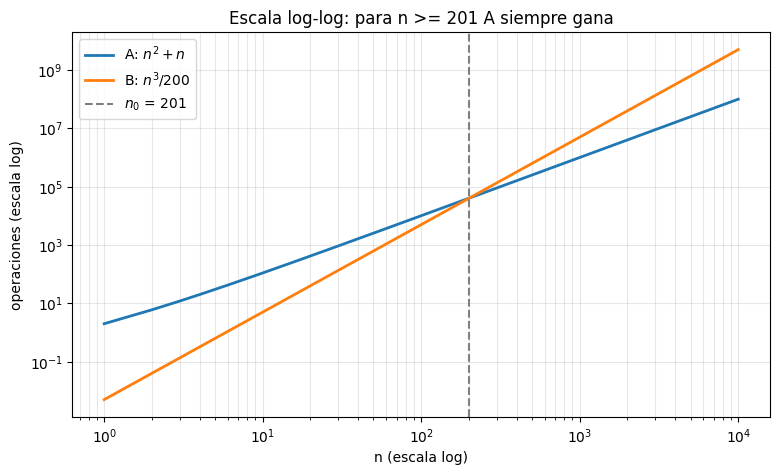

In [14]:
ns_log = list(range(1, 10001))

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(ns_log, [operaciones_A(n) for n in ns_log], label=r"A: $n^2 + n$", linewidth=2)
ax.plot(ns_log, [operaciones_B(n) for n in ns_log], label=r"B: $n^3/200$", linewidth=2)
ax.axvline(n0, color="gray", linestyle="--", label=f"$n_0$ = {n0}")

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("n (escala log)")
ax.set_ylabel("operaciones (escala log)")
ax.set_title("Escala log-log: para n >= 201 A siempre gana")
ax.legend()
ax.grid(True, which="both", alpha=0.3)
plt.show()

In [15]:
def disjointness_nlogn(A, B, C):
    a = sorted(A)
    b = sorted(B)
    c = sorted(C)

    i = 0
    j = 0
    k = 0
    while i < len(a) and j < len(b) and k < len(c):
        if a[i] == b[j] == c[k]:
            return False
        menor = min(a[i], b[j], c[k])
        if a[i] == menor:
            i = i + 1
        elif b[j] == menor:
            j = j + 1
        else:
            k = k + 1
    return True

In [16]:
def disjointness_n3(A, B, C):
    for va in A:
        for vb in B:
            for vc in C:
                if va == vb == vc:
                    return False
    return True

pruebas = [
    ([1, 2, 3], [3, 4, 5], [5, 6, 3]),
    ([1, 2, 3], [4, 5, 6], [7, 8, 9]),
    ([1, 1, 2], [2, 2, 9], [0, 2, 2]),
    ([1, 2, 3], [2, 3, 4], [4, 5, 6]),
    ([], [1], [1]),
]
for A_, B_, C_ in pruebas:
    print(A_, B_, C_, "->", disjointness_nlogn(A_, B_, C_), "| O(n^3):", disjointness_n3(A_, B_, C_))

[1, 2, 3] [3, 4, 5] [5, 6, 3] -> False | O(n^3): False
[1, 2, 3] [4, 5, 6] [7, 8, 9] -> True | O(n^3): True
[1, 1, 2] [2, 2, 9] [0, 2, 2] -> False | O(n^3): False
[1, 2, 3] [2, 3, 4] [4, 5, 6] -> True | O(n^3): True
[] [1] [1] -> True | O(n^3): True


In [17]:
def log2(x):
    x = float(x)
    exponente = 0
    while x >= 2:
        x = x / 2
        exponente = exponente + 1
    while x < 1:
        x = x * 2
        exponente = exponente - 1

    fraccion = 0.0
    peso = 0.5
    for i in range(52):
        x = x * x
        if x >= 2:
            x = x / 2
            fraccion = fraccion + peso
        peso = peso / 2
    return exponente + fraccion


def raiz_entera(t):
    r = int(t ** 0.5)
    while r * r > t:
        r = r - 1
    while (r + 1) * (r + 1) <= t:
        r = r + 1
    return r

In [18]:
tiempos = {
    "1 segundo": 10**6,
    "1 hora":    3600 * 10**6,
    "1 mes":     30 * 24 * 3600 * 10**6,
    "1 siglo":   100 * 365 * 24 * 3600 * 10**6,
}

def n_para_log(t):
    return t / log2(10)

def n_para_n(t):
    return t

def n_para_nlogn(t):
    bajo = 1
    alto = 10**17
    while bajo < alto:
        medio = (bajo + alto + 1) // 2
        if medio * log2(medio) <= t:
            bajo = medio
        else:
            alto = medio - 1
    return bajo

def n_para_n2(t):
    return raiz_entera(t)

def n_para_2n(t):
    return t.bit_length() - 1

print(f"{'f(n)':8s}" + "".join(f"{nombre:>22s}" for nombre in tiempos))
print(f"{'log n':8s}" + "".join(f"{'~10^' + format(n_para_log(t), '.6g'):>22s}" for t in tiempos.values()))
print(f"{'n':8s}" + "".join(f"{n_para_n(t):>22,}" for t in tiempos.values()))
print(f"{'n log n':8s}" + "".join(f"{n_para_nlogn(t):>22,}" for t in tiempos.values()))
print(f"{'n^2':8s}" + "".join(f"{n_para_n2(t):>22,}" for t in tiempos.values()))
print(f"{'2^n':8s}" + "".join(f"{n_para_2n(t):>22,}" for t in tiempos.values()))

f(n)                 1 segundo                1 hora                 1 mes               1 siglo
log n               ~10^301030       ~10^1.08371e+09        ~10^7.8027e+11       ~10^9.49328e+14
n                    1,000,000         3,600,000,000     2,592,000,000,000 3,153,600,000,000,000
n log n                 62,746           133,378,058        71,870,856,404    68,610,956,750,570
n^2                      1,000                60,000             1,609,968            56,156,922
2^n                         19                    31                    41                    51


In [21]:
def valor_mas_frecuente(S, n):
    conteos = [0] * (4 * n + 1)
    for valor in S:
        conteos[valor] = conteos[valor] + 1

    k = 0
    for valor in range(len(conteos)):
        if conteos[valor] > conteos[k]:
            k = valor
    return k

S = [3, 7, 3, 0, 12, 7, 3, 1]
print("valor mas frecuente:", valor_mas_frecuente(S, len(S)))

valor mas frecuente: 3


In [22]:
def busqueda_secuencial(L, x):
    for elemento in L:
        if elemento == x:
            return True
    return False

L = [8, 3, 15, 4, 9, 1, 7]
print(busqueda_secuencial(L, 15))
print(busqueda_secuencial(L, 2))

True
False


In [23]:
def busqueda_binaria(L, x):
    bajo = 0
    alto = len(L) - 1
    while bajo <= alto:
        medio = (bajo + alto) // 2
        if L[medio] == x:
            return True
        elif L[medio] < x:
            bajo = medio + 1
        else:
            alto = medio - 1
    return False

L_ordenada = [1, 3, 4, 7, 8, 9, 15]
print(busqueda_binaria(L_ordenada, 15))
print(busqueda_binaria(L_ordenada, 2))

True
False
